# 01c - CV Count Simulator Sweep

Train repeated CV-transformer simulator runs and summarize rollout R2 and CV-to-p-ratio R2 as a function of CV count.

In [1]:
# Requires: pip install -e .

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from lss.config import ExperimentConfig
from lss.data import resolve_dataset_splits
from lss.graph import build_graph
from lss.metrics import evaluate_cv_vs_global_pratio, evaluate_rollout_pratio_sides
from lss.models import create_model, resolve_model_inputs
from lss.runner import run_graph_cv_experiment
from lss.plotting import apply_editorial_style, paper_caption, style_axes
from lss.utils import resolve_device

apply_editorial_style()



/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Sweep setup.

force_train = True
cv_counts = [1, 2, 5, 10, 15, 20]
num_repeats = 2
base_seed = 675
repeat_seeds = [base_seed + i for i in range(num_repeats)]

use_decoder_local_skip = False
output_root = '../results/cv_count_simulator_sweep'

source_specs = [
    {'name': 'De Pablo', 'path': '../data/2340_dePablo_networks_OOL_undirected.pt', 'train_count': 10},
]

common_cfg = dict(
    dataset_path='mixed',
    dataset_mixture=source_specs,
    shuffle_dataset_within_source=True,
    mix_holdout_across_sources=True,
    output_root=output_root,
    pos_dim=2,
    history=1,
    train_count=sum(int(spec['train_count']) for spec in source_specs),
    val_count=20,
    limit=20,
    hidden_size=128,
    n_layers=1,
    learning_rate=1e-4,
    learning_rate_decay=0.997,
    weight_decay=0.0,
    epochs=8,
    val_every=2,
    rollout_every=2,
    cv_eval_every=2,
    freeze_normalizers_after_epoch=5,
    rollout_steps=80,
    node_features='positions',
    device='cuda',
)

def make_cfg(cv_count, repeat_idx, seed):
    return ExperimentConfig(
        run_name=f'cv_sweep_cv{cv_count:02d}_rep{repeat_idx + 1:02d}_rawcvlocalskip{int(use_decoder_local_skip)}_lean',
        model_type='cv_transformer',
        seed=seed,
        split_seed=seed,
        model_extras={
            'num_mlp': 1,
            'transformer_layers': 1,
            'transformer_heads': 1,
            'transformer_dropout': 0.001,
            'token_sizes': (240, 120, int(cv_count)),
            'use_normalization': True,
            'prediction_target': 'acceleration',
            'global_decoder_layers': 1,
            'global_decoder_local_skip': use_decoder_local_skip,
        },
        **common_cfg,
    )


In [ ]:
# Train or reuse all runs, then collect one row per run.

def _finite_best(values, mode='max'):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return float('nan')
    return float(np.max(arr) if mode == 'max' else np.min(arr))


def best_validation_rollout_checkpoint(cfg):
    run_dir = Path(cfg.output_root) / cfg.run_name
    path = run_dir / 'rollout_checkpoints.json'
    if not path.exists():
        return None, None
    entries = json.loads(path.read_text())
    candidates = [entry for entry in entries if np.isfinite(float(entry.get('rollout_r2', float('nan'))))]
    if not candidates:
        return None, None
    best = max(candidates, key=lambda entry: (float(entry['rollout_r2']), int(entry['epoch'])))
    checkpoint_path = Path(best['path'])
    if not checkpoint_path.exists():
        checkpoint_path = run_dir / 'rollout_checkpoints' / checkpoint_path.name
    return best, checkpoint_path


def saved_run_cfg(cfg):
    run_dir = Path(cfg.output_root) / cfg.run_name
    config_path = run_dir / 'config.json'
    if not config_path.exists():
        return cfg
    cfg_dict = json.loads(config_path.read_text())
    cfg_dict.pop('split_info', None)
    return ExperimentConfig(**cfg_dict)


def evaluate_best_validation_checkpoint_on_test(cfg):
    cfg = saved_run_cfg(cfg)
    best, checkpoint_path = best_validation_rollout_checkpoint(cfg)
    if best is None or checkpoint_path is None or not checkpoint_path.exists():
        return {
            'test_rollout_r2_at_best_val': float('nan'),
            'test_rollout_pearson_at_best_val': float('nan'),
            'test_rollout_pos_mse_at_best_val': float('nan'),
            'test_used': 0,
            'test_total': 0,
            'test_cv_to_pratio_r2_at_best_val': float('nan'),
            'test_cv_combo_to_pratio_r2_at_best_val': float('nan'),
            'test_cv_used': 0,
            'best_val_rollout_checkpoint': '',
        }
    device = resolve_device(cfg.device)
    train_data, val_data, test_data, split_info = resolve_dataset_splits(
        cfg.dataset_path,
        train_count=cfg.train_count,
        val_count=cfg.val_count,
        dataset_mixture=cfg.dataset_mixture,
        split_seed=cfg.split_seed,
        shuffle_within_source=cfg.shuffle_dataset_within_source,
        mix_holdout_across_sources=cfg.mix_holdout_across_sources,
    )
    if not test_data:
        return {
            'test_rollout_r2_at_best_val': float('nan'),
            'test_rollout_pearson_at_best_val': float('nan'),
            'test_rollout_pos_mse_at_best_val': float('nan'),
            'test_used': 0,
            'test_total': 0,
            'test_cv_to_pratio_r2_at_best_val': float('nan'),
            'test_cv_combo_to_pratio_r2_at_best_val': float('nan'),
            'test_cv_used': 0,
            'best_val_rollout_checkpoint': str(checkpoint_path),
        }
    model_inputs_cls = resolve_model_inputs(cfg.model_type)
    init_graph = build_graph([test_data[0][i].to(device) for i in range(cfg.history + 1)], node_features=cfg.node_features).to(device)
    model = create_model(
        model_type=cfg.model_type,
        init_graph=init_graph,
        pos_dim=cfg.pos_dim,
        hidden_size=cfg.hidden_size,
        n_layers=cfg.n_layers,
        extras=cfg.model_extras,
    ).to(device)
    model.load_checkpoint(str(checkpoint_path))
    was_training = model.training
    prev_freeze = getattr(model, 'freeze_normalizers', False)
    model.eval()
    if hasattr(model, 'freeze_normalizers'):
        model.freeze_normalizers = True
    with torch.no_grad():
        metrics = evaluate_rollout_pratio_sides(
            model=model,
            sims=test_data,
            history=cfg.history,
            rollout_steps=cfg.rollout_steps,
            pos_dim=cfg.pos_dim,
            device=device,
            model_inputs_cls=model_inputs_cls,
            node_features=cfg.node_features,
        )
        cv_metrics = evaluate_cv_vs_global_pratio(
            model=model,
            sims=test_data,
            history=cfg.history,
            pos_dim=cfg.pos_dim,
            device=device,
            max_steps=None,
            node_features=cfg.node_features,
        )
    if hasattr(model, 'freeze_normalizers'):
        model.freeze_normalizers = prev_freeze
    model.train(was_training)
    return {
        'test_rollout_r2_at_best_val': float(metrics['rollout_r2']),
        'test_rollout_pearson_at_best_val': float(metrics['rollout_pearson_r']),
        'test_rollout_pos_mse_at_best_val': float(metrics['rollout_pos_mse']),
        'test_used': int(metrics['used']),
        'test_total': int(metrics['total']),
        'test_cv_to_pratio_r2_at_best_val': float(cv_metrics.get('cv_fit_r2', float('nan'))),
        'test_cv_combo_to_pratio_r2_at_best_val': float(cv_metrics.get('cv_combo_fit_r2', float('nan'))),
        'test_cv_used': int(cv_metrics.get('cv_used', 0)),
        'best_val_rollout_checkpoint': str(checkpoint_path),
    }


def summarize_run(cfg):
    run_dir = Path(cfg.output_root) / cfg.run_name
    stats_path = run_dir / 'train_stats.pt'
    metrics_path = run_dir / 'metrics.json'
    row = {
        'run_name': cfg.run_name,
        'run_dir': str(run_dir),
        'seed': int(cfg.seed),
    }
    if stats_path.exists():
        stats = torch.load(stats_path, weights_only=False, map_location='cpu')
        row.update({
            'best_val_rollout_r2': _finite_best(stats.get('rollout_r2', [])),
            'best_val_rollout_pearson': _finite_best(stats.get('rollout_pearson_r', [])),
            'best_cv_to_pratio_r2': _finite_best(stats.get('cv_fit_r2', [])),
            'best_cv_combo_to_pratio_r2': _finite_best(stats.get('cv_combo_fit_r2', [])),
            'best_epoch_by_rollout_r2': int(stats['epoch'][int(np.nanargmax(np.asarray(stats.get('rollout_r2', [np.nan]), dtype=float)))]) if np.isfinite(_finite_best(stats.get('rollout_r2', []))) else -1,
        })
    elif metrics_path.exists():
        metrics = json.loads(metrics_path.read_text())
        row.update({
            'best_val_rollout_r2': float(metrics.get('rollout_r2', float('nan'))),
            'best_val_rollout_pearson': float(metrics.get('rollout_pearson_r', float('nan'))),
            'best_cv_to_pratio_r2': float(metrics.get('cv_fit_r2', float('nan'))),
            'best_cv_combo_to_pratio_r2': float(metrics.get('cv_combo_fit_r2', float('nan'))),
            'best_epoch_by_rollout_r2': int(metrics.get('best_epoch', -1)),
        })
    else:
        row.update({
            'best_val_rollout_r2': float('nan'),
            'best_val_rollout_pearson': float('nan'),
            'best_cv_to_pratio_r2': float('nan'),
            'best_cv_combo_to_pratio_r2': float('nan'),
            'best_epoch_by_rollout_r2': -1,
        })
    row.update(evaluate_best_validation_checkpoint_on_test(cfg))
    return row


rows = []
for cv_count in cv_counts:
    for repeat_idx, seed in enumerate(repeat_seeds):
        cfg = make_cfg(cv_count, repeat_idx, seed)
        run_dir = Path(cfg.output_root) / cfg.run_name
        need_train = force_train or not (run_dir / 'metrics.json').exists()
        paper_caption(f'CVs={cv_count}, repeat={repeat_idx + 1}: training check')
        print('run:', cfg.run_name)
        print('checkpoint:', run_dir / 'final_checkpoint.pt')
        print('training:', need_train)
        if need_train:
            run_graph_cv_experiment(cfg)
        row = summarize_run(cfg)
        row.update({'CVs': int(cv_count), 'repeat': int(repeat_idx + 1)})
        rows.append(row)

runs_df = pd.DataFrame(rows).sort_values(['CVs', 'repeat']).reset_index(drop=True)
display(runs_df.round(5))
Path(output_root).mkdir(parents=True, exist_ok=True)
runs_df.to_csv(Path(output_root) / 'cv_count_sweep_runs.csv', index=False)


In [4]:
# Aggregate mean/std over repeats per CV count, filtering failed negative-test-rollout runs.

filtered_runs_df = runs_df[runs_df['test_rollout_r2_at_best_val'].ge(0.0)].copy()
removed_runs_df = runs_df[~runs_df['test_rollout_r2_at_best_val'].ge(0.0)].copy()

paper_caption('Filtered out negative held-out test rollout R2 runs')
if len(removed_runs_df):
    display(removed_runs_df[['CVs', 'repeat', 'seed', 'best_val_rollout_r2', 'test_rollout_r2_at_best_val']].round(5))
else:
    print('No negative held-out test rollout R2 runs were filtered.')

summary_df = (
    filtered_runs_df.groupby('CVs', as_index=False)
    .agg(
        n=('test_rollout_r2_at_best_val', 'count'),
        rollout_r2_mean=('best_val_rollout_r2', 'mean'),
        rollout_r2_std=('best_val_rollout_r2', 'std'),
        test_rollout_r2_mean=('test_rollout_r2_at_best_val', 'mean'),
        test_rollout_r2_std=('test_rollout_r2_at_best_val', 'std'),
        val_cv_r2_mean=('best_cv_to_pratio_r2', 'mean'),
        val_cv_r2_std=('best_cv_to_pratio_r2', 'std'),
        val_cv_combo_r2_mean=('best_cv_combo_to_pratio_r2', 'mean'),
        val_cv_combo_r2_std=('best_cv_combo_to_pratio_r2', 'std'),
        test_cv_r2_mean=('test_cv_to_pratio_r2_at_best_val', 'mean'),
        test_cv_r2_std=('test_cv_to_pratio_r2_at_best_val', 'std'),
        test_cv_combo_r2_mean=('test_cv_combo_to_pratio_r2_at_best_val', 'mean'),
        test_cv_combo_r2_std=('test_cv_combo_to_pratio_r2_at_best_val', 'std'),
    )
)
display(summary_df.round(5))
filtered_runs_df.to_csv(Path(output_root) / 'cv_count_sweep_runs_filtered_nonnegative_test.csv', index=False)
removed_runs_df.to_csv(Path(output_root) / 'cv_count_sweep_runs_filtered_negative_test.csv', index=False)
summary_df.to_csv(Path(output_root) / 'cv_count_sweep_summary_filtered_nonnegative_test.csv', index=False)


Filtered out negative held-out test rollout R2 runs


,CVs,repeat,seed,best_val_rollout_r2,test_rollout_r2_at_best_val
0,1,1,675,-0.95207,-0.63478
1,1,2,676,-0.35624,-0.74846
2,2,1,675,-0.94744,-0.63578
3,2,2,676,-0.33142,-0.76436
4,5,1,675,-0.92067,-0.62972
5,5,2,676,-0.35490,-0.75145
6,10,1,675,-0.95167,-0.63323
7,10,2,676,-0.33242,-0.76392
8,15,1,675,-0.94511,-0.62527
9,15,2,676,-0.23369,-0.77426


,CVs,n,rollout_r2_mean,rollout_r2_std,test_rollout_r2_mean,test_rollout_r2_std,val_cv_r2_mean,val_cv_r2_std,val_cv_combo_r2_mean,val_cv_combo_r2_std,test_cv_r2_mean,test_cv_r2_std,test_cv_combo_r2_mean,test_cv_combo_r2_std


CV count sweep: simulator rollout and p-ratio encoding, negative test R2 filtered


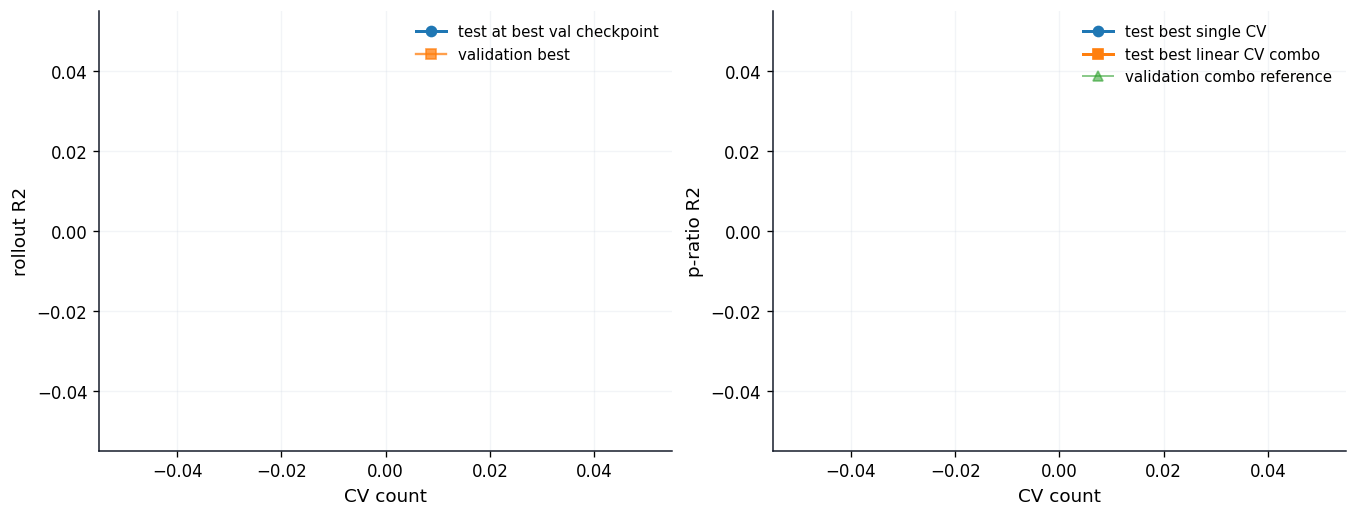

In [5]:
# Plot held-out test rollout R2 and CV-to-p-ratio R2 as a function of CV count.

paper_caption('CV count sweep: simulator rollout and p-ratio encoding, negative test R2 filtered')
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), constrained_layout=True)

axes[0].plot(summary_df['CVs'], summary_df['test_rollout_r2_mean'], marker='o', lw=1.8, label='test at best val checkpoint')
axes[0].fill_between(
    summary_df['CVs'],
    summary_df['test_rollout_r2_mean'] - summary_df['test_rollout_r2_std'].fillna(0.0),
    summary_df['test_rollout_r2_mean'] + summary_df['test_rollout_r2_std'].fillna(0.0),
    alpha=0.16,
    linewidth=0,
)
axes[0].plot(summary_df['CVs'], summary_df['rollout_r2_mean'], marker='s', lw=1.4, alpha=0.75, label='validation best')
axes[0].fill_between(
    summary_df['CVs'],
    summary_df['rollout_r2_mean'] - summary_df['rollout_r2_std'].fillna(0.0),
    summary_df['rollout_r2_mean'] + summary_df['rollout_r2_std'].fillna(0.0),
    alpha=0.10,
    linewidth=0,
)
style_axes(axes[0], xlabel='CV count', ylabel='rollout R2', legend=True)

axes[1].plot(summary_df['CVs'], summary_df['test_cv_r2_mean'], marker='o', lw=1.8, label='test best single CV')
axes[1].fill_between(
    summary_df['CVs'],
    summary_df['test_cv_r2_mean'] - summary_df['test_cv_r2_std'].fillna(0.0),
    summary_df['test_cv_r2_mean'] + summary_df['test_cv_r2_std'].fillna(0.0),
    alpha=0.16,
    linewidth=0,
)
axes[1].plot(summary_df['CVs'], summary_df['test_cv_combo_r2_mean'], marker='s', lw=1.8, label='test best linear CV combo')
axes[1].fill_between(
    summary_df['CVs'],
    summary_df['test_cv_combo_r2_mean'] - summary_df['test_cv_combo_r2_std'].fillna(0.0),
    summary_df['test_cv_combo_r2_mean'] + summary_df['test_cv_combo_r2_std'].fillna(0.0),
    alpha=0.10,
    linewidth=0,
)
axes[1].plot(summary_df['CVs'], summary_df['val_cv_combo_r2_mean'], marker='^', lw=1.2, alpha=0.55, label='validation combo reference')
style_axes(axes[1], xlabel='CV count', ylabel='p-ratio R2', legend=True)

plt.show()
fig.savefig(Path(output_root) / 'cv_count_sweep_summary_filtered_nonnegative_test.png', dpi=180)
